# Relevance filtering

### Rate relevance original prompt

In [ ]:
import json
import os
import re
from pathlib import Path
from dotenv import load_dotenv
from groq import Groq
from tqdm import tqdm

# ----------------------------
# Configuration
# ----------------------------

INPUT_PATH = "data/political_markets/comparison/articles_scored.json"
OUTPUT_PATH = "data/political_markets/comparison/articles_scored.json"

MODEL = "llama-3.3-70b-versatile"

SAVE_EVERY_N_ARTICLES = 10

# ----------------------------
# Load API keys / clients
# ----------------------------

load_dotenv()

API_KEYS = [
    os.getenv("GROQ_API_KEY_1"),
    os.getenv("GROQ_API_KEY_2"),
    os.getenv("GROQ_API_KEY_3"),
    os.getenv("GROQ_API_KEY_4"),
]

API_KEYS = [k for k in API_KEYS if k]

if not API_KEYS:
    raise ValueError("No Groq API keys found.")

clients = [Groq(api_key=key) for key in API_KEYS]

current_client_idx = 0

# ----------------------------
# Load existing scored file
# ----------------------------

with open(INPUT_PATH, "r", encoding="utf-8") as f:
    markets = json.load(f)

# ----------------------------
# Prompt template
# ----------------------------

PROMPT_TEMPLATE = """Please consider the following forecasting question and its background information. After that, I will give
you a news article and ask you to rate its relevance with respect to the forecasting question.

Question: {question}

Resolution Criteria:
{resolution_criteria}

Article:
{article}

Please rate the relevance of the article to the question, at the scale of 1-6

1 – irrelevant
2 – slightly relevant
3 – somewhat relevant
4 – relevant
5 – highly relevant
6 – most relevant

Guidelines:
- You don’t need to access any external sources. Just consider the information provided.
- Focus on the content of the article, not the title.
- If the text content is an error message about JavaScript, paywall, cookies or other technical issues,
output a score of 1.

Your response should look like the following:

Thought: {{ Insert your thinking }}
Rating: {{ Insert answer here }}
"""

# ----------------------------
# Helper functions
# ----------------------------

def extract_thought_and_rating(response_text):
    """
    Extract:
    - thought (string)
    - rating (int)
    """

    thought_match = re.search(
        r"Thought:\s*(.*?)(?:Rating:|$)",
        response_text,
        re.DOTALL | re.IGNORECASE,
    )

    rating_match = re.search(
        r"Rating:\s*([1-6])",
        response_text,
        re.IGNORECASE,
    )

    thought = (
        thought_match.group(1).strip()
        if thought_match
        else None
    )

    rating = (
        int(rating_match.group(1))
        if rating_match
        else None
    )

    return thought, rating


def save_progress():
    Path(OUTPUT_PATH).parent.mkdir(parents=True, exist_ok=True)
    with open(OUTPUT_PATH, "w", encoding="utf-8") as f:
        json.dump(markets, f, ensure_ascii=False, indent=2)


def get_completion_with_failover(messages):
    global current_client_idx

    num_clients = len(clients)
    attempts = 0

    while attempts < num_clients:

        client = clients[current_client_idx]

        try:
            completion = client.chat.completions.create(
                model=MODEL,
                messages=messages,
                temperature=0,
            )

            return completion

        except Exception as e:
            error_text = str(e).lower()

            quota_error = any(
                phrase in error_text
                for phrase in [
                    "rate limit",
                    "quota",
                    "credit",
                    "exceeded",
                    "insufficient",
                    "429",
                ]
            )

            if quota_error:
                print(
                    f"\nAPI key #{current_client_idx + 1} exhausted or rate-limited. "
                    f"Switching to next key..."
                )

                current_client_idx = (current_client_idx + 1) % num_clients
                attempts += 1

            else:
                raise e

    raise RuntimeError("All Groq API keys failed or exhausted.")


def score_article(question, resolution_criteria, article_text):

    prompt = PROMPT_TEMPLATE.format(
        question=question,
        resolution_criteria=resolution_criteria,
        article=article_text,
    )

    completion = get_completion_with_failover(
        messages=[
            {
                "role": "user",
                "content": prompt,
            }
        ]
    )

    response_text = completion.choices[0].message.content

    thought, rating = extract_thought_and_rating(response_text)

    return {
        "llm_response": response_text,
        "thought": thought,
        "rating": rating,
    }


# ----------------------------
# Count remaining articles
# ----------------------------

articles_to_process = []

for market in markets:

    for query_obj in market.get("queries", []):

        for article in query_obj.get("articles", []):

            if article.get("rating") is None:
                articles_to_process.append((market, article))

print(f"Articles remaining: {len(articles_to_process)}")

# ----------------------------
# Process only missing ratings
# ----------------------------

processed_since_save = 0

progress_bar = tqdm(
    total=len(articles_to_process),
    desc="Scoring missing articles",
)

for market, article in articles_to_process:

    question = market.get("question", "")
    resolution_criteria = market.get("resolution_criteria", "")

    article_text = article.get("full_text", "")

    try:
        result = score_article(
            question=question,
            resolution_criteria=resolution_criteria,
            article_text=article_text,
        )

        article["llm_response"] = result["llm_response"]
        article["thought"] = result["thought"]
        article["rating"] = result["rating"]

        # remove previous error if retry succeeds
        if "error" in article:
            del article["error"]

    except Exception as e:

        article["llm_response"] = None
        article["thought"] = None
        article["rating"] = None
        article["error"] = str(e)

        print(f"\nError: {e}")

    processed_since_save += 1
    progress_bar.update(1)

    # periodic checkpoint save
    if processed_since_save >= SAVE_EVERY_N_ARTICLES:
        save_progress()
        processed_since_save = 0
        print("\nProgress saved.")

progress_bar.close()

# ----------------------------
# Final save
# ----------------------------

save_progress()

print(f"Finished. Updated file saved to: {OUTPUT_PATH}")

Articles remaining: 331


Scoring missing articles:   3%|▎         | 10/331 [00:27<27:16,  5.10s/it]


Progress saved.


Scoring missing articles:   6%|▌         | 20/331 [01:48<36:58,  7.13s/it]


Progress saved.


...


API key #2 exhausted or rate-limited. Switching to next key...

API key #3 exhausted or rate-limited. Switching to next key...

Error: All Groq API keys failed or exhausted.

API key #4 exhausted or rate-limited. Switching to next key...

API key #1 exhausted or rate-limited. Switching to next key...

API key #2 exhausted or rate-limited. Switching to next key...

API key #3 exhausted or rate-limited. Switching to next key...

Error: All Groq API keys failed or exhausted.


Scoring missing articles: 100%|█████████▉| 330/331 [11:04<00:00,  6.65it/s]


API key #4 exhausted or rate-limited. Switching to next key...

API key #1 exhausted or rate-limited. Switching to next key...

API key #2 exhausted or rate-limited. Switching to next key...

API key #3 exhausted or rate-limited. Switching to next key...

Error: All Groq API keys failed or exhausted.

Progress saved.

API key #4 exhausted or rate-limited. Switching to next key...


Scoring missing articles: 100%|██████████| 331/331 [11:04<00:00,  2.01s/it]


API key #1 exhausted or rate-limited. Switching to next key...

API key #2 exhausted or rate-limited. Switching to next key...

API key #3 exhausted or rate-limited. Switching to next key...

Error: All Groq API keys failed or exhausted.
Finished. Updated file saved to: data/political_markets/comparison/articles_scored.json


Total rated articles: 310
Average score: 2.813


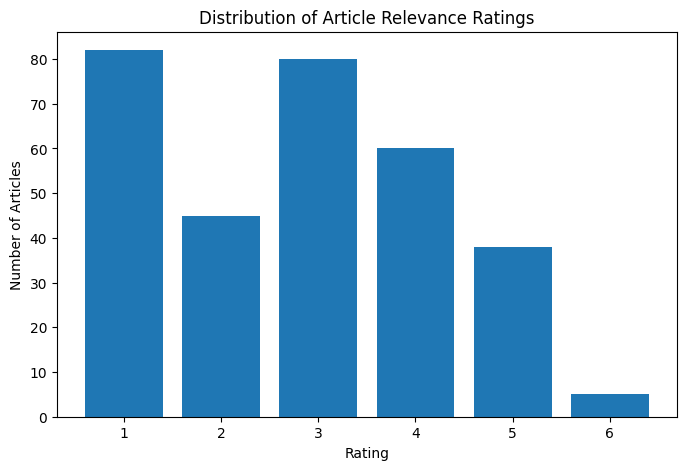

In [ ]:
import json
from collections import Counter

import matplotlib.pyplot as plt

# ----------------------------
# Load scored dataset
# ----------------------------

INPUT_PATH = "data/political_markets/comparison/articles_scored.json"

with open(INPUT_PATH, "r", encoding="utf-8") as f:
    markets = json.load(f)

# ----------------------------
# Collect ratings
# ----------------------------

ratings = []

for market in markets:
    for query_obj in market.get("queries", []):
        for article in query_obj.get("articles", []):

            rating = article.get("rating")

            if isinstance(rating, int):
                ratings.append(rating)

# ----------------------------
# Summary statistics
# ----------------------------

total_rated_articles = len(ratings)

average_score = (
    sum(ratings) / total_rated_articles
    if total_rated_articles > 0
    else 0
)

print(f"Total rated articles: {total_rated_articles}")
print(f"Average score: {average_score:.3f}")

# ----------------------------
# Rating distribution
# ----------------------------

rating_counts = Counter(ratings)

x = [1, 2, 3, 4, 5, 6]
y = [rating_counts.get(i, 0) for i in x]

# ----------------------------
# Bar plot
# ----------------------------

plt.figure(figsize=(8, 5))
plt.bar(x, y)

plt.xticks(x)
plt.xlabel("Rating")
plt.ylabel("Number of Articles")
plt.title("Distribution of Article Relevance Ratings")

plt.show()

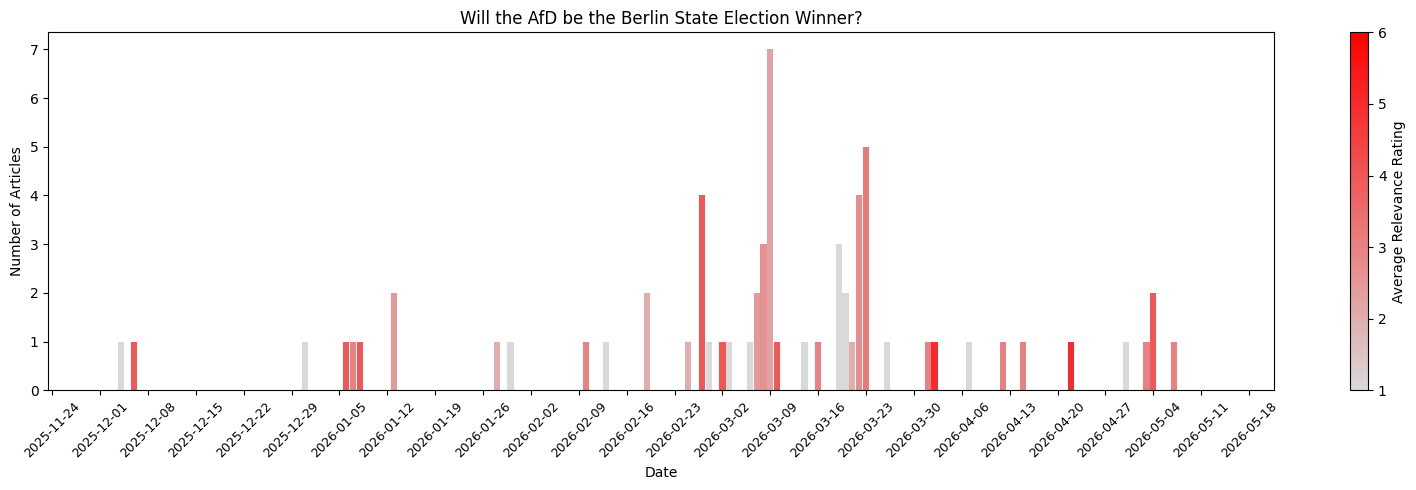

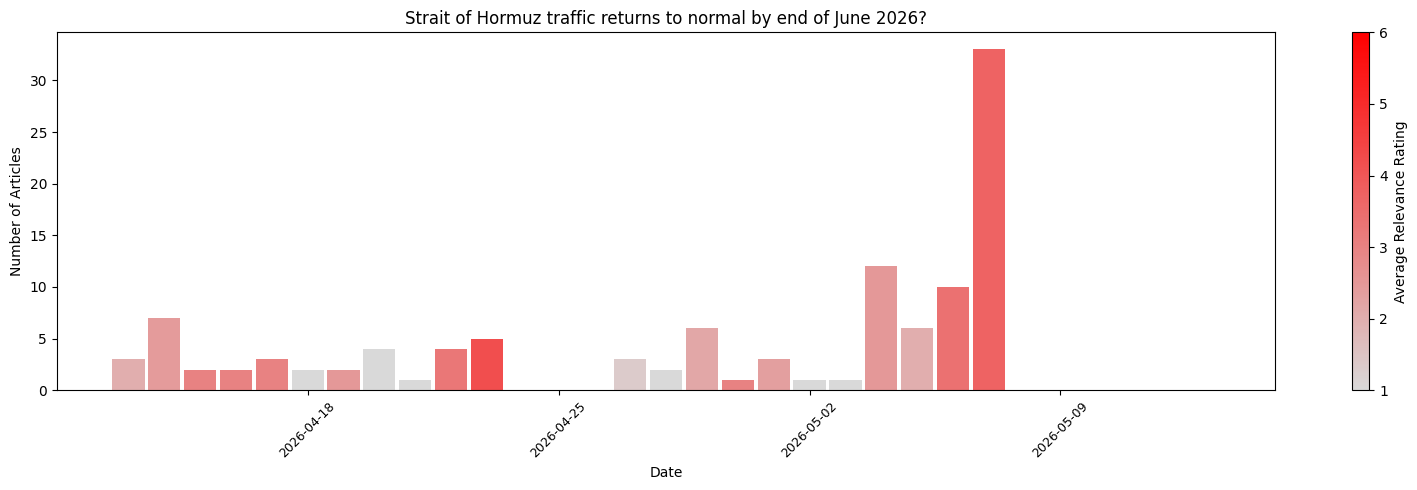

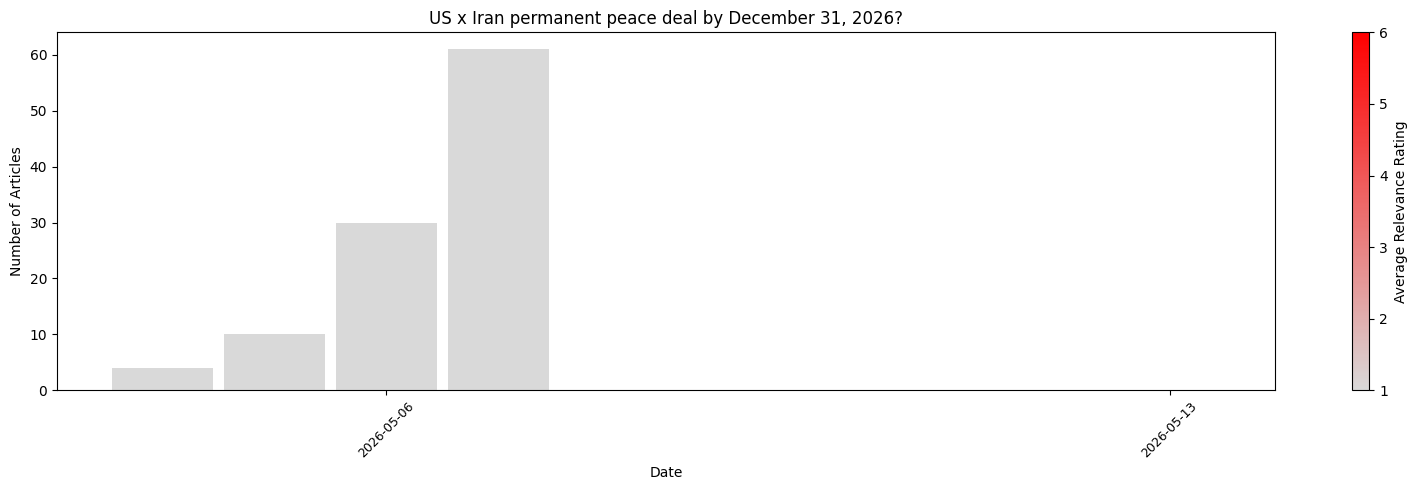

In [ ]:
import json
from collections import defaultdict
from datetime import datetime, timezone
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import pandas as pd
import matplotlib.dates as mdates
from matplotlib.colors import LinearSegmentedColormap

SCORED_PATH = "data/political_markets/comparison/articles_scored.json"
MARKETS_PATH = "data/political_markets/markets.json"

with open(SCORED_PATH, "r", encoding="utf-8") as f:
    scored_markets = json.load(f)

with open(MARKETS_PATH, "r", encoding="utf-8") as f:
    markets_metadata = json.load(f)

market_lookup = {}

for market in markets_metadata:

    question = market.get("question")
    start_date = market.get("start_date")

    if question and start_date:
        market_lookup[question] = start_date

today = datetime.now(timezone.utc).date()

# ============================================================
# Create one plot per market
# ============================================================

for market in scored_markets:

    question = market.get("question", "Unknown Market")

    if question not in market_lookup:
        print(f"Skipping market (missing start_date): {question}")
        continue

    # --------------------------------------------------------
    # Parse start date
    # --------------------------------------------------------

    start_date = pd.to_datetime(
        market_lookup[question],
        utc=True,
        errors="coerce",
    )

    if pd.isna(start_date):
        print(f"Skipping market (invalid start_date): {question}")
        continue

    start_date = start_date.date()

    # --------------------------------------------------------
    # Aggregate per-day statistics
    # --------------------------------------------------------

    articles_per_day = defaultdict(int)
    ratings_per_day = defaultdict(list)

    for query_obj in market.get("queries", []):

        for article in query_obj.get("articles", []):

            published_date = article.get("published_date")

            if not published_date:
                continue

            published_dt = pd.to_datetime(
                published_date,
                utc=True,
                errors="coerce",
            )

            if pd.isna(published_dt):
                continue

            published_day = published_dt.date()

            # filter by start_date -> today
            if not (start_date <= published_day <= today):
                continue

            rating = article.get("rating")

            # missing ratings count as 1
            if not isinstance(rating, int):
                rating = 1

            articles_per_day[published_day] += 1
            ratings_per_day[published_day].append(rating)

    # --------------------------------------------------------
    # Skip empty markets
    # --------------------------------------------------------

    if not articles_per_day:
        print(f"No articles in range for: {question}")
        continue

    # --------------------------------------------------------
    # Create continuous date range
    # --------------------------------------------------------

    all_days = pd.date_range(start=start_date, end=today, freq="D")

    counts = []
    avg_ratings = []

    for day in all_days:

        d = day.date()

        counts.append(articles_per_day.get(d, 0))

        ratings = ratings_per_day.get(d, [])

        if ratings:
            avg_ratings.append(sum(ratings) / len(ratings))
        else:
            avg_ratings.append(1)

    # --------------------------------------------------------
    # Normalize colors by average rating
    # --------------------------------------------------------

    norm = mcolors.Normalize(vmin=1, vmax=6)

    # light grey -> bright red
    cmap = LinearSegmentedColormap.from_list(
        "grey_to_red",
        ["#d9d9d9", "#ff0000"]
    )

    colors = [cmap(norm(r)) for r in avg_ratings]

    # --------------------------------------------------------
    # Plot
    # --------------------------------------------------------

    plt.figure(figsize=(16, 5))

    plt.bar(
        all_days,
        counts,
        color=colors,
        width=0.9,
    )

    plt.xlabel("Date")
    plt.ylabel("Number of Articles")
    plt.title(question)

    ax = plt.gca()

    # more frequent x-axis labels
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=7))

    # format labels
    ax.xaxis.set_major_formatter(
        mdates.DateFormatter("%Y-%m-%d")
    )

    plt.xticks(rotation=45, fontsize=9)

    # colorbar for average relevance
    ax = plt.gca()

    sm = cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])

    cbar = plt.colorbar(sm, ax=ax)
    cbar.set_label("Average Relevance Rating")

    plt.tight_layout()
    plt.show()

In [ ]:
from collections import defaultdict
import pandas as pd

# ------------------------------------------------------------
# Print days where average relevance rating > 4
# ------------------------------------------------------------

for market in scored_markets:

    question = market.get("question", "Unknown Market")

    ratings_per_day = defaultdict(list)

    for query_obj in market.get("queries", []):

        for article in query_obj.get("articles", []):

            published_date = article.get("published_date")

            if not published_date:
                continue

            published_dt = pd.to_datetime(
                published_date,
                utc=True,
                errors="coerce",
            )

            if pd.isna(published_dt):
                continue

            published_day = published_dt.date()

            rating = article.get("rating")

            # missing ratings count as 1
            if not isinstance(rating, int):
                rating = 1

            ratings_per_day[published_day].append(rating)

    high_relevance_days = []

    for day, ratings in ratings_per_day.items():

        avg_rating = sum(ratings) / len(ratings)

        if avg_rating > 4:
            high_relevance_days.append(
                (day, round(avg_rating, 2), len(ratings))
            )

    if high_relevance_days:

        print(f"\n=== {question} ===")

        for day, avg_rating, n_articles in sorted(high_relevance_days):

            print(
                f"{day} | avg rating = {avg_rating} | "
                f"articles = {n_articles}"
            )


=== Will the AfD be the Berlin State Election Winner? ===
2016-09-18 | avg rating = 5.0 | articles = 1
2025-01-25 | avg rating = 5.0 | articles = 1
2025-03-03 | avg rating = 4.5 | articles = 2
2025-10-30 | avg rating = 5.0 | articles = 2
2026-04-02 | avg rating = 5.0 | articles = 1
2026-04-22 | avg rating = 5.0 | articles = 1

=== Strait of Hormuz traffic returns to normal by end of June 2026? ===
2026-03-10 | avg rating = 5.0 | articles = 1
2026-03-18 | avg rating = 5.0 | articles = 1
2026-04-05 | avg rating = 6.0 | articles = 1
2026-04-10 | avg rating = 6.0 | articles = 1
2026-04-12 | avg rating = 5.0 | articles = 1
2026-04-23 | avg rating = 4.2 | articles = 5


### Rate relevance prompt with published date

In [ ]:
# PROMPT WITH PUBLISHED DATE

import json
import os
import re
from pathlib import Path

from dotenv import load_dotenv
from groq import Groq
from tqdm import tqdm

INPUT_PATH = "data/political_markets/comparison/articles_scored.json"
OUTPUT_PATH = "data/political_markets/comparison/articles_scored_2.json"

MODEL = "llama-3.3-70b-versatile"

SAVE_EVERY_N_ARTICLES = 10

load_dotenv()

API_KEYS = [
    os.getenv("GROQ_API_KEY_1"),
    os.getenv("GROQ_API_KEY_2"),
    os.getenv("GROQ_API_KEY_3"),
    os.getenv("GROQ_API_KEY_4"),
]

API_KEYS = [k for k in API_KEYS if k]

if not API_KEYS:
    raise ValueError("No Groq API keys found.")

clients = [Groq(api_key=key) for key in API_KEYS]

current_client_idx = 0

with open(INPUT_PATH, "r", encoding="utf-8") as f:
    markets = json.load(f)

PROMPT_TEMPLATE = """Please consider the following forecasting question and its background information. After that, I will give
you a news article and ask you to rate its relevance with respect to the forecasting question.

Question: {question}

Resolution Criteria:
{resolution_criteria}

Article:
{article}

Article Published Date: {published_date}

Please rate the relevance of the article to the question, at the scale of 1-6

1 – irrelevant
2 – slightly relevant
3 – somewhat relevant
4 – relevant
5 – highly relevant
6 – most relevant

Guidelines:
- You don’t need to access any external sources. Just consider the information provided.
- Focus on the content of the article, not the title.
- If the text content is an error message about JavaScript, paywall, cookies or other technical issues,
output a score of 1.

Your response should look like the following:

Thought: {{ Insert your thinking }}
Rating: {{ Insert answer here }}
"""

# ----------------------------
# Helper functions
# ----------------------------

def extract_thought_and_rating(response_text):

    thought_match = re.search(
        r"Thought:\s*(.*?)(?:Rating:|$)",
        response_text,
        re.DOTALL | re.IGNORECASE,
    )

    rating_match = re.search(
        r"Rating:\s*([1-6])",
        response_text,
        re.IGNORECASE,
    )

    thought = (
        thought_match.group(1).strip()
        if thought_match
        else None
    )

    rating = (
        int(rating_match.group(1))
        if rating_match
        else None
    )

    return thought, rating


def save_progress():
    Path(OUTPUT_PATH).parent.mkdir(parents=True, exist_ok=True)

    with open(OUTPUT_PATH, "w", encoding="utf-8") as f:
        json.dump(markets, f, ensure_ascii=False, indent=2)


def get_completion_with_failover(messages):
    global current_client_idx

    num_clients = len(clients)
    attempts = 0

    while attempts < num_clients:

        client = clients[current_client_idx]

        try:
            completion = client.chat.completions.create(
                model=MODEL,
                messages=messages,
                temperature=0,
            )

            return completion

        except Exception as e:
            error_text = str(e).lower()

            quota_error = any(
                phrase in error_text
                for phrase in [
                    "rate limit",
                    "quota",
                    "credit",
                    "exceeded",
                    "insufficient",
                    "429",
                ]
            )

            if quota_error:
                print(
                    f"\nAPI key #{current_client_idx + 1} exhausted or rate-limited. "
                    f"Switching to next key..."
                )

                current_client_idx = (current_client_idx + 1) % num_clients
                attempts += 1

            else:
                raise e

    raise RuntimeError("All Groq API keys failed or exhausted.")


def score_article(question, resolution_criteria, article_text, published_date):

    prompt = PROMPT_TEMPLATE.format(
        question=question,
        resolution_criteria=resolution_criteria,
        article=article_text,
        published_date=published_date
    )

    completion = get_completion_with_failover(
        messages=[
            {
                "role": "user",
                "content": prompt,
            }
        ]
    )

    response_text = completion.choices[0].message.content

    thought, rating = extract_thought_and_rating(response_text)

    return {
        "llm_response": response_text,
        "thought": thought,
        "rating": rating,
    }

articles_to_process = []

for market in markets:

    for query_obj in market.get("queries", []):

        for article in query_obj.get("articles", []):

            if article.get("rating") is None:
                articles_to_process.append((market, article))

print(f"Articles remaining: {len(articles_to_process)}")

processed_since_save = 0

progress_bar = tqdm(
    total=len(articles_to_process),
    desc="Scoring missing articles",
)

for market, article in articles_to_process:

    question = market.get("question", "")
    resolution_criteria = market.get("resolution_criteria", "")
    article_text = article.get("full_text", "")
    published_date = article.get("published_date", "")

    try:
        result = score_article(
            question=question,
            resolution_criteria=resolution_criteria,
            article_text=article_text,
            published_date=published_date
        )

        article["llm_response"] = result["llm_response"]
        article["thought"] = result["thought"]
        article["rating"] = result["rating"]

        # remove previous error if retry succeeds
        if "error" in article:
            del article["error"]

    except Exception as e:

        article["llm_response"] = None
        article["thought"] = None
        article["rating"] = None
        article["error"] = str(e)

        print(f"\nError: {e}")

    processed_since_save += 1
    progress_bar.update(1)

    # periodic checkpoint save
    if processed_since_save >= SAVE_EVERY_N_ARTICLES:
        save_progress()
        processed_since_save = 0
        print("\nProgress saved.")

progress_bar.close()

save_progress()

print(f"Finished. Updated file saved to: {OUTPUT_PATH}")

Articles remaining: 331


Scoring missing articles:  48%|████▊     | 160/331 [13:49:11<14:46:12, 310.95s/it]


KeyboardInterrupt: 

In [ ]:
import json
from collections import Counter

import matplotlib.pyplot as plt

# ----------------------------
# Load scored dataset
# ----------------------------

INPUT_PATH = "data/political_markets/comparison/articles_scored_2.json"

with open(INPUT_PATH, "r", encoding="utf-8") as f:
    markets = json.load(f)

# ----------------------------
# Collect ratings
# ----------------------------

ratings = []

for market in markets:
    for query_obj in market.get("queries", []):
        for article in query_obj.get("articles", []):

            rating = article.get("rating")

            if isinstance(rating, int):
                ratings.append(rating)

# ----------------------------
# Summary statistics
# ----------------------------

total_rated_articles = len(ratings)

average_score = (
    sum(ratings) / total_rated_articles
    if total_rated_articles > 0
    else 0
)

print(f"Total rated articles: {total_rated_articles}")
print(f"Average score: {average_score:.3f}")

# ----------------------------
# Rating distribution
# ----------------------------

rating_counts = Counter(ratings)

x = [1, 2, 3, 4, 5, 6]
y = [rating_counts.get(i, 0) for i in x]

# ----------------------------
# Bar plot
# ----------------------------

plt.figure(figsize=(8, 5))
plt.bar(x, y)

plt.xticks(x)
plt.xlabel("Rating")
plt.ylabel("Number of Articles")
plt.title("Distribution of Article Relevance Ratings")

plt.show()

### Comparison 2x2 (with/without date & score/probability)

In [ ]:
import json
import os
import re
from pathlib import Path
from dotenv import load_dotenv
from groq import Groq
from tqdm import tqdm

INPUT_PATH = "data/political_markets/comparison/articles_gnews_package_standard.json"

OUTPUT_PATH = (
    "data/political_markets/comparison/"
    "articles_gnews_package_standard_prompt_eval.json"
)

PROMPTS_DIR = "prompts/relevance"

MODEL = "llama-3.3-70b-versatile"

N_MARKETS_EXAMINED = 1

SAVE_EVERY = 5


load_dotenv()

API_KEYS = [
    os.getenv("GROQ_API_KEY_1"),
    os.getenv("GROQ_API_KEY_2"),
    os.getenv("GROQ_API_KEY_3"),
    os.getenv("GROQ_API_KEY_4"),
]

API_KEYS = [k for k in API_KEYS if k]

if not API_KEYS:
    raise ValueError("No Groq API keys found.")

clients = [Groq(api_key=k) for k in API_KEYS]

current_client_idx = 0

# ============================================================
# Load dataset
# ============================================================

if os.path.exists(OUTPUT_PATH):

    print("Loading existing progress file...")

    with open(OUTPUT_PATH, "r", encoding="utf-8") as f:
        markets = json.load(f)

else:

    print("Loading original dataset...")

    with open(INPUT_PATH, "r", encoding="utf-8") as f:
        markets = json.load(f)

# ============================================================
# Restrict to first N markets
# ============================================================

markets = markets[:N_MARKETS_EXAMINED]

# ============================================================
# Load prompts
# ============================================================

prompt_files = {
    "p1_without": "score_without_date.txt",
    "p1_with": "score_with_date.txt",
    "p2_without": "probability_without_date.txt",
    "p2_with": "probability_with_date.txt",
}

prompts = {}

for key, filename in prompt_files.items():

    with open(
        os.path.join(PROMPTS_DIR, filename),
        "r",
        encoding="utf-8",
    ) as f:

        prompts[key] = f.read()

# ============================================================
# Helpers
# ============================================================

def save_progress():

    Path(OUTPUT_PATH).parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    with open(OUTPUT_PATH, "w", encoding="utf-8") as f:
        json.dump(
            markets,
            f,
            ensure_ascii=False,
            indent=2,
        )


def extract_rating(text):

    match = re.search(
        r"Rating:\s*([0-9]+)",
        text,
        re.IGNORECASE,
    )

    if match:
        return int(match.group(1))

    return None


def extract_probability(text):

    match = re.search(
        r"Probability:\s*([0-9]+(?:\.[0-9]+)?)",
        text,
        re.IGNORECASE,
    )

    if match:
        return float(match.group(1))

    return None


def extract_thought(text):

    match = re.search(
        r"Thought:\s*(.*?)(?:Rating:|Probability:|$)",
        text,
        re.DOTALL | re.IGNORECASE,
    )

    if match:
        return match.group(1).strip()

    return None


def get_completion_with_failover(messages):

    global current_client_idx

    n = len(clients)

    attempts = 0

    while attempts < n:

        client = clients[current_client_idx]

        try:

            completion = client.chat.completions.create(
                model=MODEL,
                messages=messages,
                temperature=0,
            )

            return completion

        except Exception as e:

            error_text = str(e).lower()

            quota_error = any(
                phrase in error_text
                for phrase in [
                    "rate limit",
                    "quota",
                    "credit",
                    "429",
                    "insufficient",
                    "exceeded",
                ]
            )

            if quota_error:

                print(
                    f"\nKey #{current_client_idx + 1} exhausted. "
                    f"Switching..."
                )

                current_client_idx = (
                    current_client_idx + 1
                ) % n

                attempts += 1

            else:
                raise e

    raise RuntimeError(
        "All API keys exhausted."
    )


def fill_prompt(
    template,
    question,
    resolution_criteria,
    article,
    published_date,
):

    return template.format(
        question=question,
        resolution_criteria=resolution_criteria,
        article=article,
        published_date=published_date,
    )


def process_prompt(
    article_obj,
    field_response,
    field_value,
    field_thought,
    prompt_text,
    value_type,
):

    # already done
    if article_obj.get(field_response) is not None:
        return False

    completion = get_completion_with_failover(
        [
            {
                "role": "user",
                "content": prompt_text,
            }
        ]
    )

    response_text = completion.choices[0].message.content

    article_obj[field_response] = response_text

    article_obj[field_thought] = extract_thought(
        response_text
    )

    if value_type == "rating":

        article_obj[field_value] = extract_rating(
            response_text
        )

    elif value_type == "probability":

        article_obj[field_value] = extract_probability(
            response_text
        )

    return True


# ============================================================
# Count remaining tasks
# ============================================================

remaining = 0

for market in markets:
    for query_obj in market.get("queries", []):
        for article in query_obj.get("articles", []):

            fields = [
                "response_p1_without",
                "response_p1_with",
                "response_p2_without",
                "response_p2_with",
            ]

            for f in fields:
                if article.get(f) is None:
                    remaining += 1

print(f"Remaining prompt calls: {remaining}")

# ============================================================
# Main loop
# ============================================================

processed_since_save = 0

progress_bar = tqdm(total=remaining)

try:

    for market in markets:

        question = market.get("question", "")
        resolution_criteria = market.get(
            "resolution_criteria",
            "",
        )

        for query_obj in market.get("queries", []):

            for article in query_obj.get("articles", []):

                article_text = article.get(
                    "full_text",
                    "",
                )

                published_date = article.get(
                    "published_date",
                    "",
                )

                # ------------------------------------------------
                # Prompt 1 without date
                # ------------------------------------------------

                prompt = fill_prompt(
                    prompts["p1_without"],
                    question,
                    resolution_criteria,
                    article_text,
                    published_date,
                )

                did_work = process_prompt(
                    article_obj=article,
                    field_response="response_p1_without",
                    field_value="score_p1_without",
                    field_thought="thought_p1_without",
                    prompt_text=prompt,
                    value_type="rating",
                )

                if did_work:
                    progress_bar.update(1)
                    processed_since_save += 1

                # ------------------------------------------------
                # Prompt 1 with date
                # ------------------------------------------------

                prompt = fill_prompt(
                    prompts["p1_with"],
                    question,
                    resolution_criteria,
                    article_text,
                    published_date,
                )

                did_work = process_prompt(
                    article_obj=article,
                    field_response="response_p1_with",
                    field_value="score_p1_with",
                    field_thought="thought_p1_with",
                    prompt_text=prompt,
                    value_type="rating",
                )

                if did_work:
                    progress_bar.update(1)
                    processed_since_save += 1

                # ------------------------------------------------
                # Prompt 2 without date
                # ------------------------------------------------

                prompt = fill_prompt(
                    prompts["p2_without"],
                    question,
                    resolution_criteria,
                    article_text,
                    published_date,
                )

                did_work = process_prompt(
                    article_obj=article,
                    field_response="response_p2_without",
                    field_value="probability_p2_without",
                    field_thought="thought_p2_without",
                    prompt_text=prompt,
                    value_type="probability",
                )

                if did_work:
                    progress_bar.update(1)
                    processed_since_save += 1

                # ------------------------------------------------
                # Prompt 2 with date
                # ------------------------------------------------

                prompt = fill_prompt(
                    prompts["p2_with"],
                    question,
                    resolution_criteria,
                    article_text,
                    published_date,
                )

                did_work = process_prompt(
                    article_obj=article,
                    field_response="response_p2_with",
                    field_value="probability_p2_with",
                    field_thought="thought_p2_with",
                    prompt_text=prompt,
                    value_type="probability",
                )

                if did_work:
                    progress_bar.update(1)
                    processed_since_save += 1

                # ------------------------------------------------
                # Periodic save
                # ------------------------------------------------

                if processed_since_save >= SAVE_EVERY:

                    save_progress()

                    processed_since_save = 0

                    print("\nProgress saved.")

except RuntimeError as e:

    print(f"\nSTOPPING: {e}")

finally:

    save_progress()

    progress_bar.close()

    print(
        f"\nSaved progress to:\n{OUTPUT_PATH}"
    )

In [3]:
import pandas as pd
import json

# Read the Excel file
df = pd.read_excel('data/news/prob_markets_with_llm_stances.xlsx')

# Initialize list for all markets
markets = []

for _, row in df.iterrows():
    # Build market base info
    market = {
        "category": row['category'],
        "statement": row['statement'],
        "curr_prob_yes": row['curr_prob_yes'],
        "market_start_date": row['market_start_date'],
        "market_link": row['market_link'],
        "prob_without_article": row['prob_without_article'],
        "queries": [
            {
                "query": row['query'],
                "articles": []
            }
        ]
    }
    
    # Article 01
    article_01 = {
        "source": row.get('source_01', None),
        "alignment": row.get('source_01_alignment', None),
        "title": row.get('title_01_orignal', None),
        "url": row.get('article_01_link', None),
        "published_date": row.get('article_01_date', None),
        "full_text": row.get('article_01_original', None),
        "relevance": row.get('relevance_01', None),
        "helpfulness": row.get('helpfulness_01', None),
        "stance": row.get('stance_01', None),
        "title_left": row.get('title_01_left', None),
        "article_left": row.get('article_01_left', None),
        "title_right": row.get('title_01_right', None),
        "article_right": row.get('article_01_right', None),
        "prob_original": row.get('prob_original_01', None),
        "prob_left": row.get('prob_left_01', None),
        "prob_right": row.get('prob_right_01', None),
        "llm_stance": row.get('llm_stance_01', None),
        "llm_reason": row.get('llm_reason_01', None)
    }
    market['queries'][0]['articles'].append(article_01)
    
    # Article 02
    article_02 = {
        "source": row.get('source_02', None),
        "alignment": row.get('source_02_alignment', None),
        "title": row.get('title_02_orignal', None),
        "url": row.get('article_02_link', None),
        "published_date": row.get('article_02_date', None),
        "full_text": row.get('article_02_original', None),
        "relevance": row.get('relevance_02', None),
        "helpfulness": row.get('helpfulness_02', None),
        "stance": row.get('stance_02', None),
        "title_left": row.get('title_02_left', None),
        "article_left": row.get('article_02_left', None),
        "title_right": row.get('title_02_right', None),
        "article_right": row.get('article_02_right', None),
        "prob_original": row.get('prob_original_02', None),
        "prob_left": row.get('prob_left_02', None),
        "prob_right": row.get('prob_right_02', None),
        "llm_stance": row.get('llm_stance_02', None),
        "llm_reason": row.get('llm_reason_02', None)
    }
    market['queries'][0]['articles'].append(article_02)
    
    # Article 03
    article_03 = {
        "source": row.get('source_03', None),
        "alignment": row.get('source_03_alignment', None),
        "title": row.get('title_03_orignal', None),
        "url": row.get('article_03_link', None),
        "published_date": row.get('article_03_date', None),
        "full_text": row.get('article_03_original', None),
        "relevance": row.get('relevance_03', None),
        "helpfulness": row.get('helpfulness_03', None),
        "stance": row.get('stance_03', None),
        "title_left": row.get('title_03_left', None),
        "article_left": row.get('article_03_left', None),
        "title_right": row.get('title_03_right', None),
        "article_right": row.get('article_03_right', None),
        "prob_original": row.get('prob_original_03', None),
        "prob_left": row.get('prob_left_03', None),
        "prob_right": row.get('prob_right_03', None),
        "llm_stance": row.get('llm_stance_03', None),
        "llm_reason": row.get('llm_reason_03', None)
    }
    market['queries'][0]['articles'].append(article_03)
    
    # Article 04 (unrelated)
    article_unrelated = {
        "source": row.get('source_unrelated', None),
        "alignment": None,
        "title": row.get('title_unrelated', None),
        "url": row.get('article_unrelated_link', None),
        "published_date": row.get('article_unrelated_date', None),
        "full_text": row.get('article_unrelated', None),
        "relevance": None,
        "helpfulness": None,
        "stance": None,
        "title_left": None,
        "article_left": None,
        "title_right": None,
        "article_right": None,
        "prob_original": row.get('prob_unrelated', None),
        "prob_left": None,
        "prob_right": None,
        "llm_stance": row.get('llm_stance_unrelated', None),
        "llm_reason": row.get('llm_reason_unrelated', None)
    }
    market['queries'][0]['articles'].append(article_unrelated)
    
    markets.append(market)

# Write to JSON file
with open('markets_output.json', 'w', encoding='utf-8') as f:
    json.dump(markets, f, indent=2, default=str)

print(f"Done! Converted {len(markets)} markets to markets_output.json")

Done! Converted 5 markets to markets_output.json
